# 03 — Feature Engineering

The goal of this step is to turn the cleaned question pairs into numeric pair features that can be used later in modeling.

At this stage, we stay inside feature engineering: lexical overlap, fuzzy matching, and sparse text similarity.  
We reuse the saved output from preprocessing and keep the final result as a separate feature table.

In practice, this step helps translate the cleaned text into signals that can capture similarity more directly than the raw questions alone.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from project_bootstrap import setup_project

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [3]:
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_CANDIDATE = NOTEBOOK_DIR if (NOTEBOOK_DIR / "project_bootstrap.py").exists() else NOTEBOOK_DIR.parent

if str(PROJECT_CANDIDATE) not in sys.path:
    sys.path.insert(0, str(PROJECT_CANDIDATE))

PROJECT_ROOT = setup_project()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

%load_ext autoreload
%autoreload 2

from feature_engineering import (
    build_basic_pair_features,
    build_feature_table,
    build_fuzzy_features,
    build_sparse_similarity_features,
    get_feature_groups,
    get_numeric_feature_columns,
    load_preprocessed_dataset,
)

## 1. Load the preprocessed dataset

We start from the saved output of the preprocessing notebook instead of rebuilding the text cleanup here.

This keeps the feature engineering step focused on numeric signals rather than raw text normalization.

In [4]:
df = load_preprocessed_dataset(PROJECT_ROOT)

preview_cols = [
    col for col in ["id", "question1", "question2", "q1_norm", "q2_norm", "q1_classic", "q2_classic", "is_duplicate"]
    if col in df.columns
]

print(f"Dataset shape: {df.shape}")
df[preview_cols].head()

Dataset shape: (323432, 10)


,id,question1,question2,q1_norm,q2_norm,q1_classic,q2_classic,is_duplicate
0,332278,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,the iliad and the odyssey in the greek culture,how do i prove that the pairs of three indepen...,iliad odyssey greek culture,prove pairs three independent variables also i...,0
1,196656,What is practical management and what is strat...,What are the practical aspects of strategic ma...,what is practical management and what is strat...,what are the practical aspects of strategic ma...,practical management strategic management,practical aspects strategic management,0
2,113125,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,how useful is makeuseof answers,is there any q a site that is not yahoo answer...,useful makeuseof answers,q site yahoo answers hate speech allowed,0
3,266232,Which is the best place to reside in India and...,Which ia the best place to visit in India?,which is the best place to reside in india and...,which ia the best place to visit in india,best place reside india,ia best place visit india,0
4,122738,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,why do so many people ask questions on quora t...,why do not many people posting questions on qu...,many people ask questions quora easily answere...,many people posting questions quora check goog...,1


## 2. Basic lexical and length features

This first feature group stays close to the cleaned text itself.

We use the normalized text version to build simple pair features such as:
- word and character counts;
- absolute length differences;
- overlap ratios;
- exact match and first/last word checks;
- token and bigram overlap measures.

In [5]:
basic_features = build_basic_pair_features(df, q1_col="q1_norm", q2_col="q2_norm")

print(f"Basic feature frame shape: {basic_features.shape}")
basic_features.head()

Basic feature frame shape: (323432, 21)


,exact_match,q1_word_count,q2_word_count,q1_char_count,q2_char_count,word_count_diff,char_count_diff,mean_word_count,mean_char_count,first_word_eq,last_word_eq,common_word_count,common_non_stopword_count,total_unique_word_count,word_jaccard,non_stopword_jaccard,word_overlap_min,word_overlap_max,bigram_jaccard,word_count_ratio,char_count_ratio
0,0,9,14,46,80,5,34,11.5,63.0,0,0,1,0,19,0.052632,0.000000,0.142857,0.076923,0.000000,0.642857,0.575000
1,0,9,8,61,54,1,7,8.5,57.5,1,1,4,3,10,0.400000,0.750000,0.666667,0.500000,0.076923,0.888889,0.885246
2,0,5,16,31,76,11,45,10.5,53.5,0,0,2,1,17,0.117647,0.111111,0.400000,0.142857,0.000000,0.312500,0.407895
3,0,11,9,50,41,2,9,10.0,45.5,1,0,7,3,13,0.538462,0.500000,0.777778,0.636364,0.285714,0.818182,0.820000
4,0,31,12,157,68,19,89,21.5,112.5,1,0,9,5,32,0.281250,0.294118,0.750000,0.310345,0.108108,0.387097,0.433121


In [6]:
basic_features.describe().T.round(3).head(20)

,count,mean,std,min,25%,50%,75%,max
exact_match,323432.0,0.004,0.059,0.0,0.000,0.000,0.000,1.0
q1_word_count,323432.0,11.131,5.577,0.0,7.000,10.000,13.000,128.0
q2_word_count,323432.0,11.384,6.496,0.0,7.000,10.000,13.000,248.0
q1_char_count,323432.0,58.188,29.504,0.0,38.000,51.000,70.000,604.0
q2_char_count,323432.0,58.776,33.420,0.0,38.000,50.000,70.000,1141.0
word_count_diff,323432.0,3.777,4.975,0.0,1.000,2.000,5.000,233.0
char_count_diff,323432.0,19.876,25.175,0.0,4.000,11.000,25.000,1071.0
mean_word_count,323432.0,11.257,5.188,0.0,8.000,10.000,13.500,140.5
mean_char_count,323432.0,58.482,27.139,0.0,40.000,52.000,70.500,644.5
first_word_eq,323432.0,0.514,0.500,0.0,0.000,1.000,1.000,1.0


## 3. Visualize the basic features

For this kind of task, it is useful to look at how engineered features behave across the two target classes.

To keep the plots readable, we clip only the display range at the 99th percentile where needed.  
The saved features themselves are not trimmed or modified.

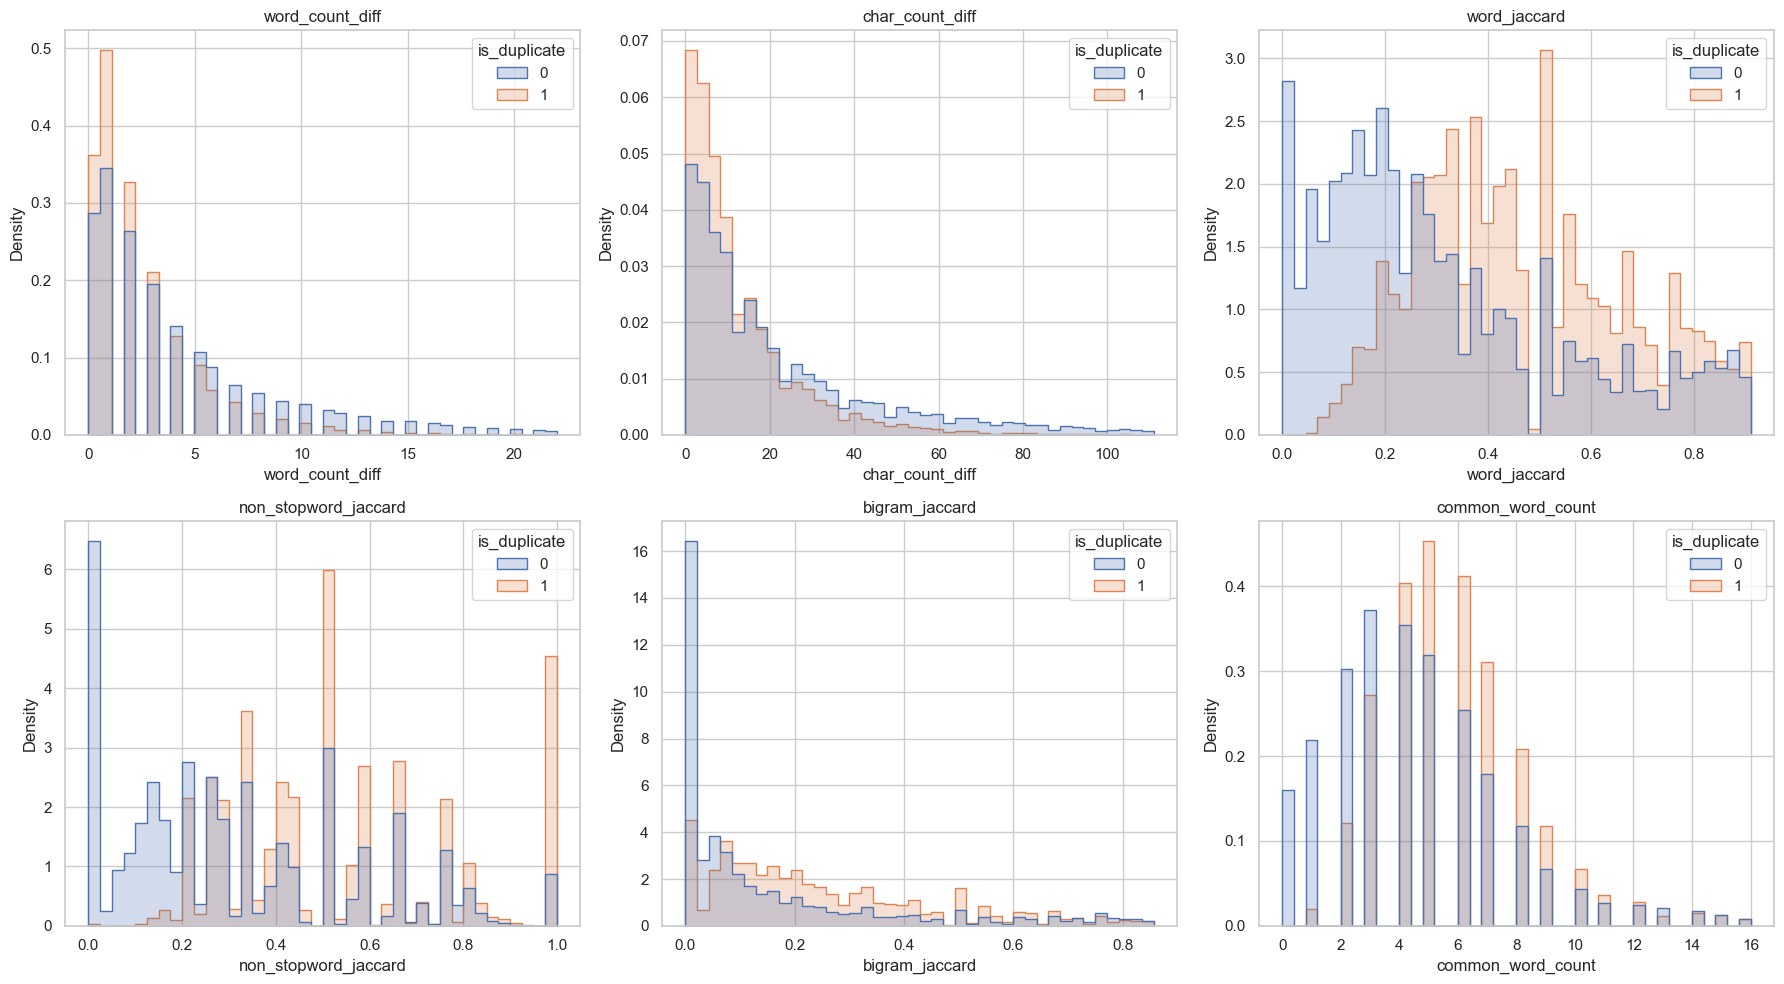

In [7]:
feature_groups = get_feature_groups()
target_col = "is_duplicate"

plot_df = pd.concat([df[[target_col]].reset_index(drop=True), basic_features], axis=1)
plot_sample = plot_df.sample(min(len(plot_df), 60000), random_state=42)

selected_basic = [
    "word_count_diff",
    "char_count_diff",
    "word_jaccard",
    "non_stopword_jaccard",
    "bigram_jaccard",
    "common_word_count",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature in zip(axes, selected_basic):
    upper = plot_sample[feature].quantile(0.99)
    view = plot_sample[plot_sample[feature] <= upper].copy()
    sns.histplot(
        data=view,
        x=feature,
        hue=target_col,
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax,
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()

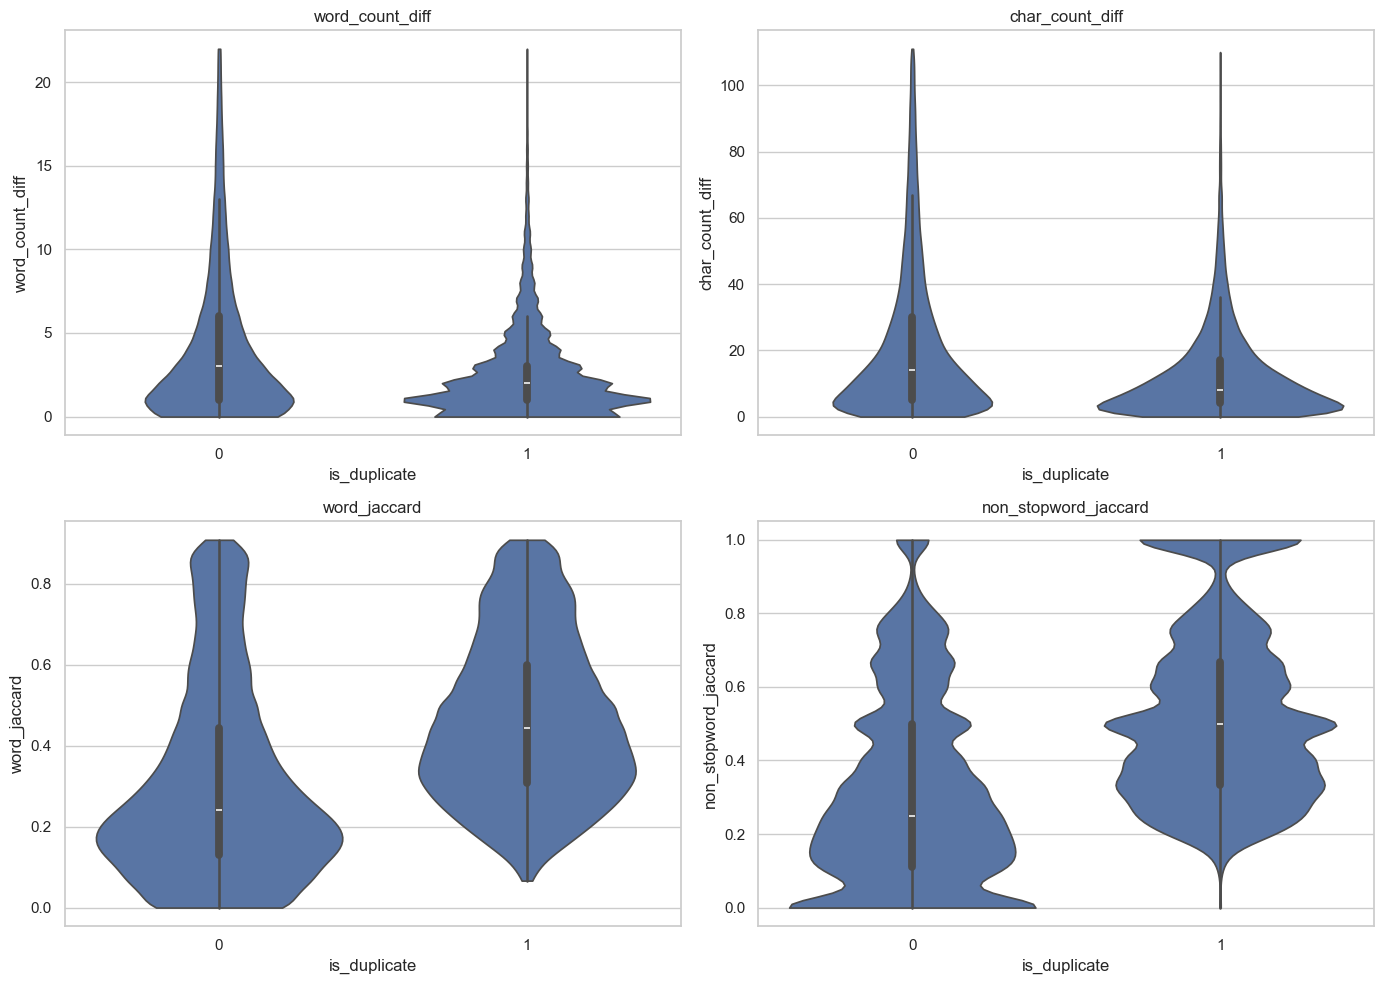

In [8]:
violin_basic = [
    "word_count_diff",
    "char_count_diff",
    "word_jaccard",
    "non_stopword_jaccard",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feature in zip(axes, violin_basic):
    upper = plot_sample[feature].quantile(0.99)
    view = plot_sample[plot_sample[feature] <= upper].copy()
    sns.violinplot(data=view, x=target_col, y=feature, ax=ax, cut=0)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

## 4. Fuzzy string-matching features

The next feature group compares the two cleaned questions more directly as strings.

These features are often useful in duplicate-question tasks because they can capture:
- very close rephrasings;
- token reordering;
- partial matches;
- shared substrings even when the wording is not identical.

In [9]:
fuzzy_features = build_fuzzy_features(df, q1_col="q1_norm", q2_col="q2_norm")

print(f"Fuzzy feature frame shape: {fuzzy_features.shape}")
fuzzy_features.head()

Fuzzy feature frame shape: (323432, 5)


,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio,longest_substr_ratio
0,34.920635,44.943820,41.269841,33.962264,0.108696
1,71.304348,68.292683,74.782609,90.909091,0.388889
2,33.644860,54.838710,35.514019,48.780488,0.258065
3,81.318681,87.804878,70.329670,87.671233,0.463415
4,48.000000,75.438596,47.111111,82.758621,0.294118


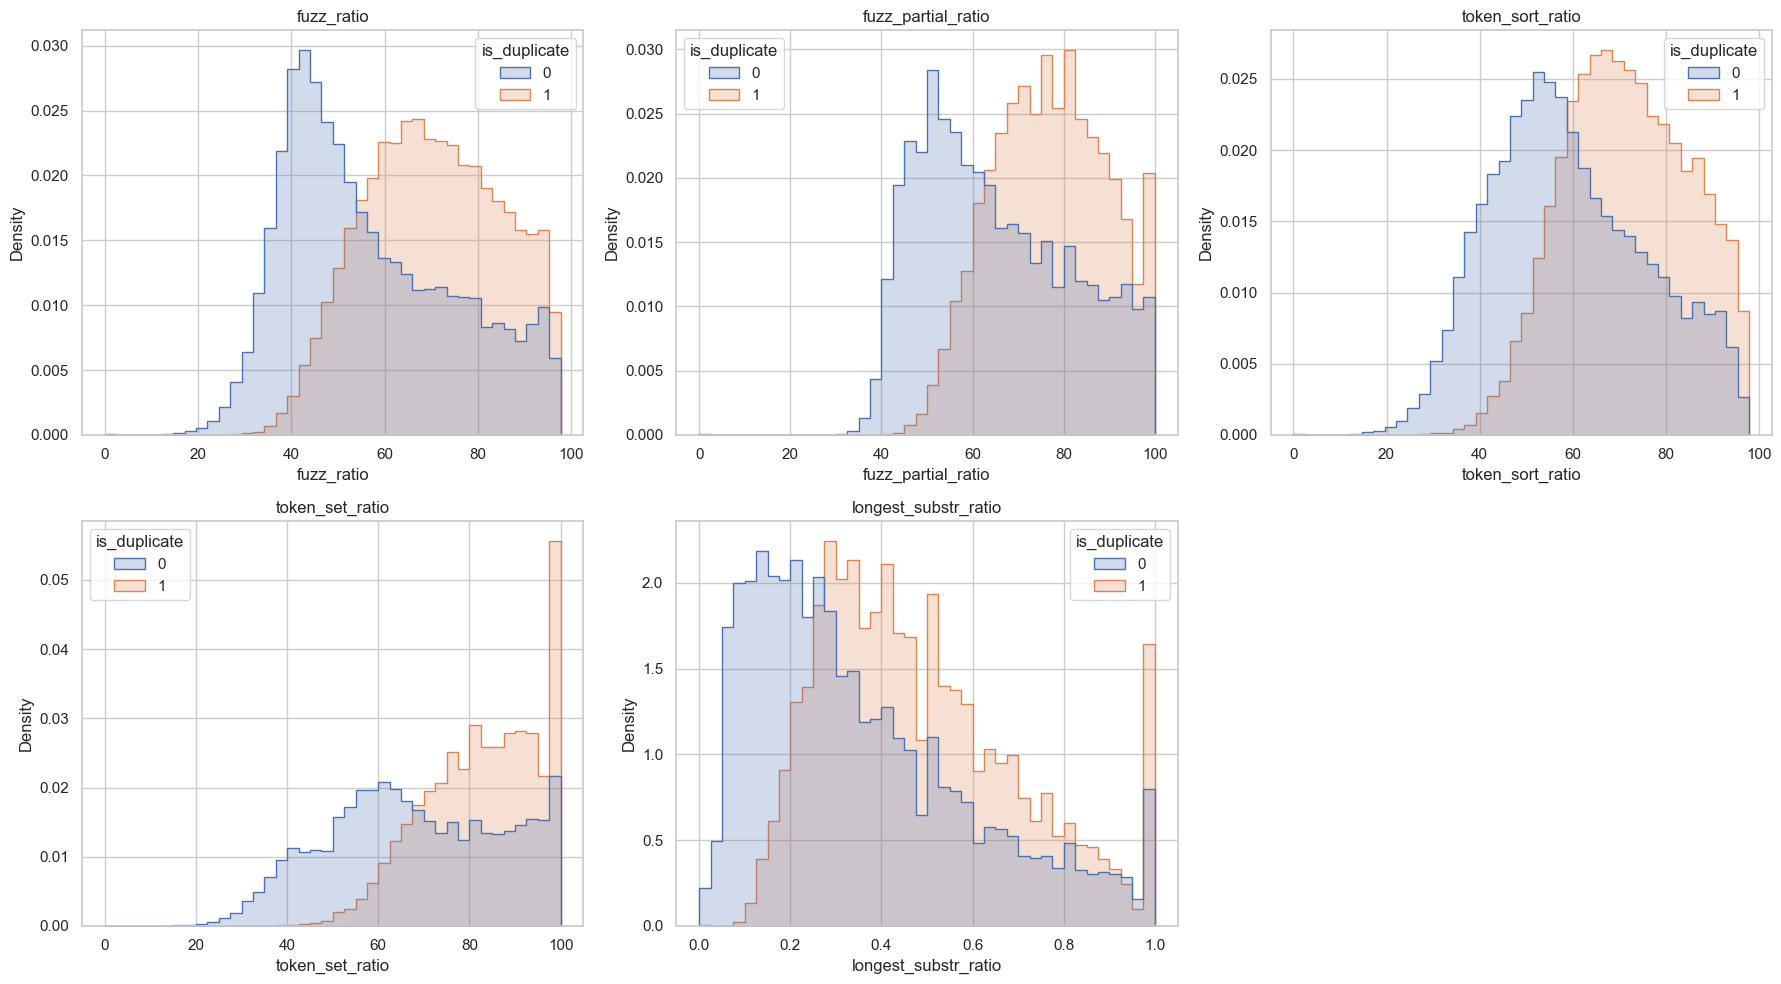

In [10]:
fuzzy_plot_df = pd.concat([df[[target_col]].reset_index(drop=True), fuzzy_features], axis=1)
fuzzy_sample = fuzzy_plot_df.sample(min(len(fuzzy_plot_df), 60000), random_state=42)

selected_fuzzy = [
    "fuzz_ratio",
    "fuzz_partial_ratio",
    "token_sort_ratio",
    "token_set_ratio",
    "longest_substr_ratio",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature in zip(axes, selected_fuzzy):
    upper = fuzzy_sample[feature].quantile(0.99)
    view = fuzzy_sample[fuzzy_sample[feature] <= upper].copy()
    sns.histplot(
        data=view,
        x=feature,
        hue=target_col,
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax,
    )
    ax.set_title(feature)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

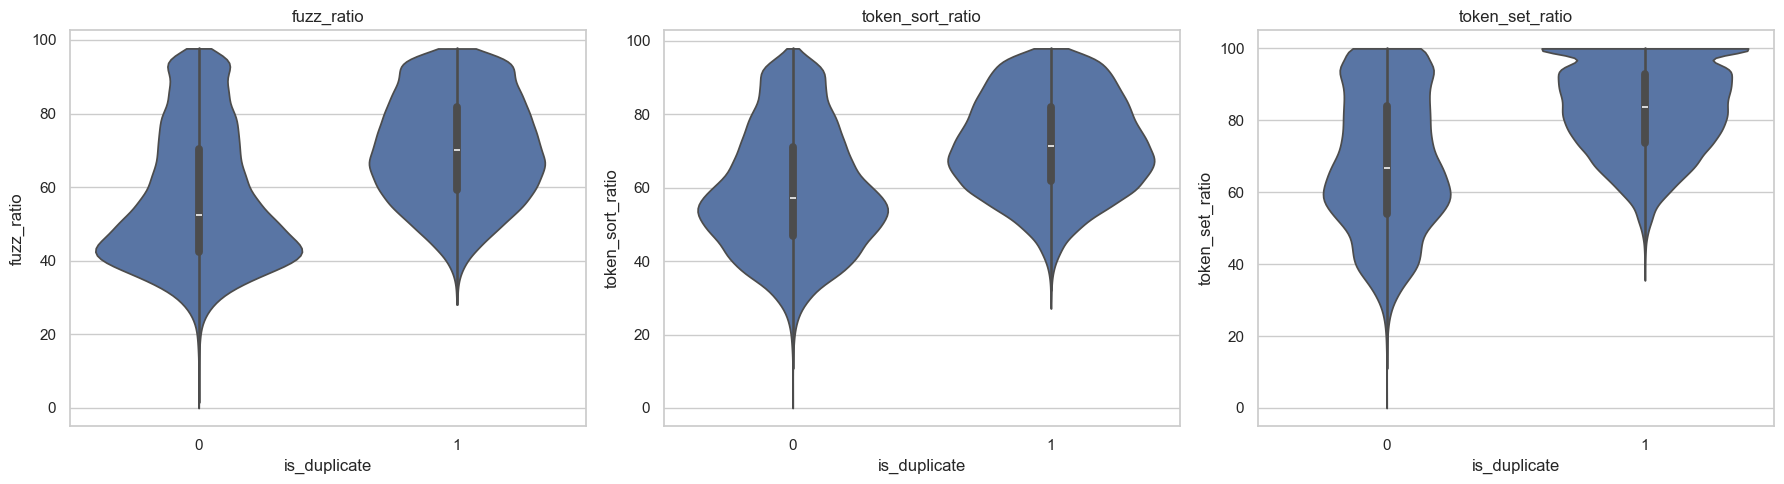

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, ["fuzz_ratio", "token_sort_ratio", "token_set_ratio"]):
    upper = fuzzy_sample[feature].quantile(0.99)
    view = fuzzy_sample[fuzzy_sample[feature] <= upper].copy()
    sns.violinplot(data=view, x=target_col, y=feature, ax=ax, cut=0)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

## 5. Sparse text similarity features

Now we build pairwise similarity features from sparse vector representations.

For this step we use the `q1_classic / q2_classic` text version from preprocessing, because it is more compact and more suitable for count-based vectorizers such as:
- Bag of Words;
- TF-IDF.

For each representation, we compute cosine, Euclidean, and Manhattan distances between the two question vectors.

In [12]:
bow_features = build_sparse_similarity_features(
    df,
    q1_col="q1_classic",
    q2_col="q2_classic",
    method="bow",
    prefix="bow",
)

tfidf_features = build_sparse_similarity_features(
    df,
    q1_col="q1_classic",
    q2_col="q2_classic",
    method="tfidf",
    prefix="tfidf",
)

sparse_features = pd.concat([bow_features, tfidf_features], axis=1)

print(f"Sparse similarity frame shape: {sparse_features.shape}")
sparse_features.head()

Sparse similarity frame shape: (323432, 6)


,bow_cosine,bow_euclidean,bow_manhattan,tfidf_cosine,tfidf_euclidean,tfidf_manhattan
0,0.000000,3.464102,10,0.000000,1.414214,4.068060
1,0.816497,1.414214,2,0.847734,0.551844,0.785760
2,0.267261,2.645751,7,0.219413,1.249470,3.375859
3,0.632456,2.236068,5,0.396429,1.098700,2.709021
4,0.347833,5.291503,28,0.176252,1.283548,6.882932


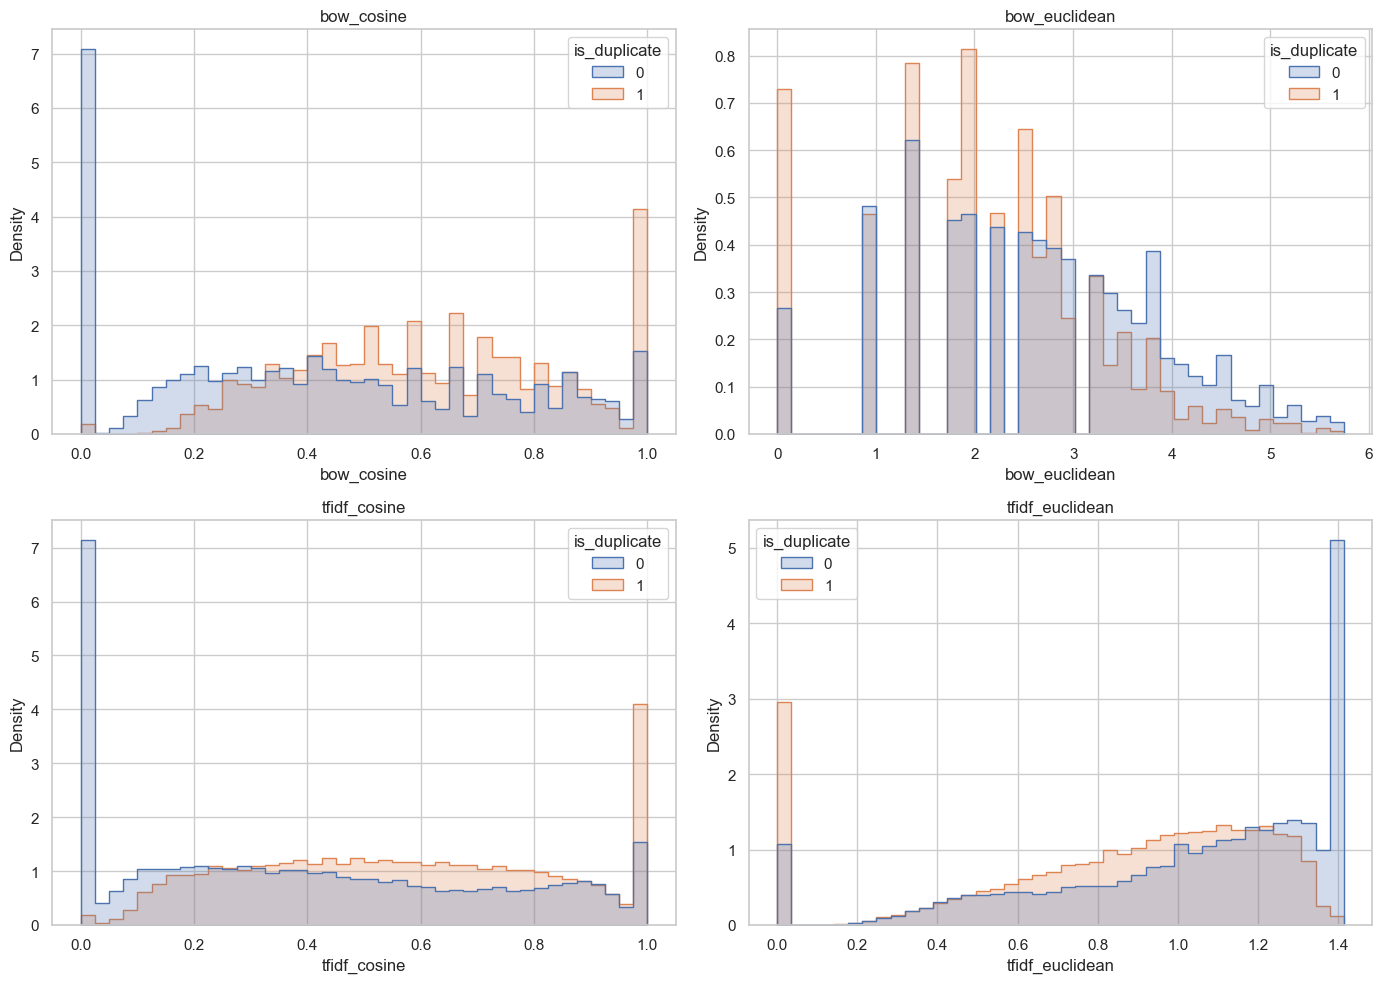

In [13]:
sparse_plot_df = pd.concat([df[[target_col]].reset_index(drop=True), sparse_features], axis=1)
sparse_sample = sparse_plot_df.sample(min(len(sparse_plot_df), 60000), random_state=42)

selected_sparse = [
    "bow_cosine",
    "bow_euclidean",
    "tfidf_cosine",
    "tfidf_euclidean",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feature in zip(axes, selected_sparse):
    upper = sparse_sample[feature].quantile(0.99)
    view = sparse_sample[sparse_sample[feature] <= upper].copy()
    sns.histplot(
        data=view,
        x=feature,
        hue=target_col,
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax,
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()

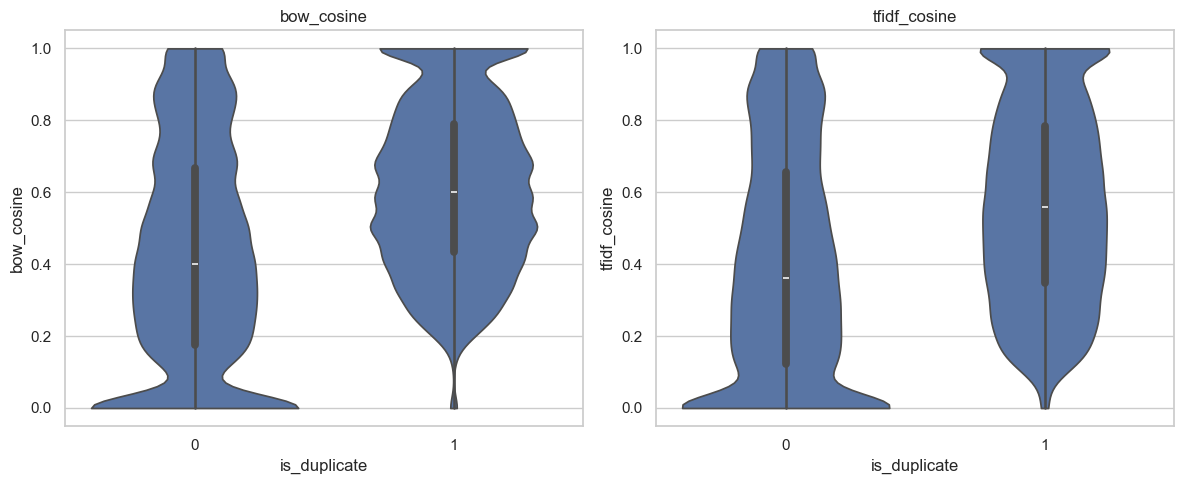

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature in zip(axes, ["bow_cosine", "tfidf_cosine"]):
    upper = sparse_sample[feature].quantile(0.99)
    view = sparse_sample[sparse_sample[feature] <= upper].copy()
    sns.violinplot(data=view, x=target_col, y=feature, ax=ax, cut=0)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

## 6. Combine all engineered features

At this point, we bring the feature groups together into one reusable table.

The final table keeps the row identifier and target column, then appends:
- basic lexical features;
- fuzzy features;
- BoW similarity features;
- TF-IDF similarity features.

In [15]:
feature_table = build_feature_table(df)

feature_csv_path = PROCESSED_DIR / "pair_similarity_features.csv"
feature_parquet_path = PROCESSED_DIR / "pair_similarity_features.parquet"

feature_table.to_csv(feature_csv_path, index=False)
feature_table.to_parquet(feature_parquet_path, index=False)

print(f"Feature table shape: {feature_table.shape}")
print(f"Saved CSV: {feature_csv_path.name}")
print(f"Saved Parquet: {feature_parquet_path.name}")

feature_table.head()

Feature table shape: (323432, 34)
Saved CSV: pair_similarity_features.csv
Saved Parquet: pair_similarity_features.parquet


,id,is_duplicate,exact_match,q1_word_count,q2_word_count,q1_char_count,q2_char_count,word_count_diff,char_count_diff,mean_word_count,mean_char_count,first_word_eq,last_word_eq,common_word_count,common_non_stopword_count,total_unique_word_count,word_jaccard,non_stopword_jaccard,word_overlap_min,word_overlap_max,bigram_jaccard,word_count_ratio,char_count_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio,longest_substr_ratio,bow_cosine,bow_euclidean,bow_manhattan,tfidf_cosine,tfidf_euclidean,tfidf_manhattan
0,332278,0,0,9,14,46,80,5,34,11.5,63.0,0,0,1,0,19,0.052632,0.000000,0.142857,0.076923,0.000000,0.642857,0.575000,34.920635,44.943820,41.269841,33.962264,0.108696,0.000000,3.464102,10,0.000000,1.414214,4.068060
1,196656,0,0,9,8,61,54,1,7,8.5,57.5,1,1,4,3,10,0.400000,0.750000,0.666667,0.500000,0.076923,0.888889,0.885246,71.304348,68.292683,74.782609,90.909091,0.388889,0.816497,1.414214,2,0.847734,0.551844,0.785760
2,113125,0,0,5,16,31,76,11,45,10.5,53.5,0,0,2,1,17,0.117647,0.111111,0.400000,0.142857,0.000000,0.312500,0.407895,33.644860,54.838710,35.514019,48.780488,0.258065,0.267261,2.645751,7,0.219413,1.249470,3.375859
3,266232,0,0,11,9,50,41,2,9,10.0,45.5,1,0,7,3,13,0.538462,0.500000,0.777778,0.636364,0.285714,0.818182,0.820000,81.318681,87.804878,70.329670,87.671233,0.463415,0.632456,2.236068,5,0.396429,1.098700,2.709021
4,122738,1,0,31,12,157,68,19,89,21.5,112.5,1,0,9,5,32,0.281250,0.294118,0.750000,0.310345,0.108108,0.387097,0.433121,48.000000,75.438596,47.111111,82.758621,0.294118,0.347833,5.291503,28,0.176252,1.283548,6.882932


## 7. Correlation structure and class-level patterns

Once the full feature table is ready, it is useful to inspect:
- which features move together;
- which groups look redundant;
- which features separate the two classes more clearly on average.

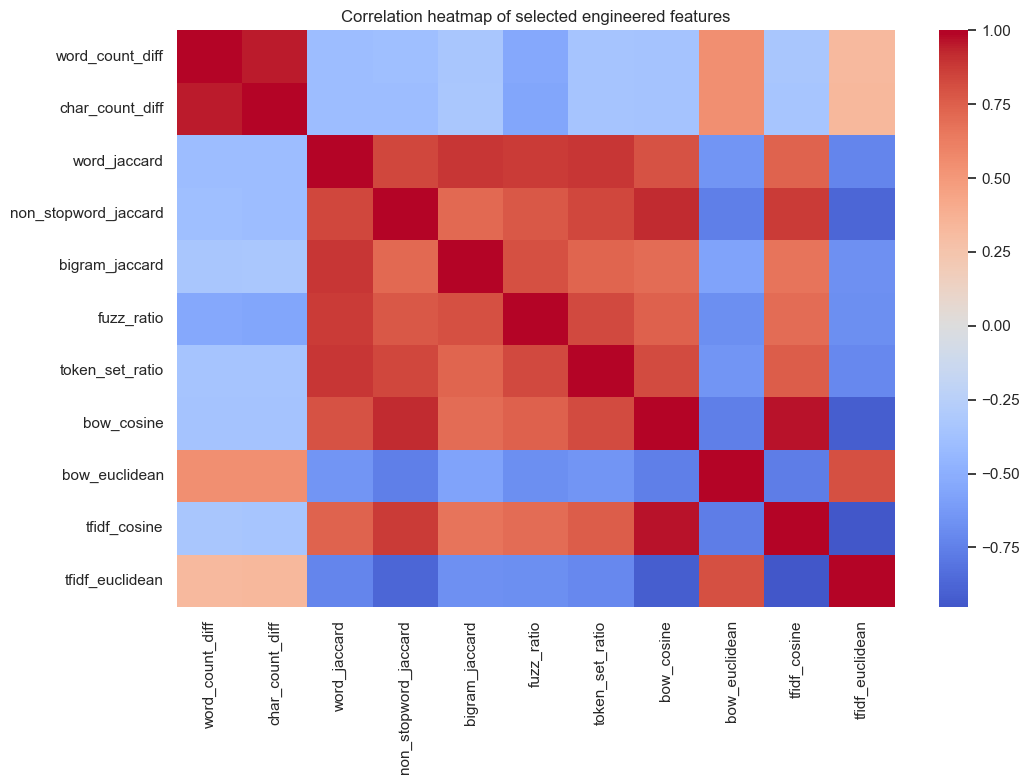

In [16]:
numeric_cols = get_numeric_feature_columns(feature_table)
corr_cols = [
    "word_count_diff",
    "char_count_diff",
    "word_jaccard",
    "non_stopword_jaccard",
    "bigram_jaccard",
    "fuzz_ratio",
    "token_set_ratio",
    "bow_cosine",
    "bow_euclidean",
    "tfidf_cosine",
    "tfidf_euclidean",
]

corr_cols = [col for col in corr_cols if col in feature_table.columns]

plt.figure(figsize=(11, 8))
sns.heatmap(feature_table[corr_cols].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation heatmap of selected engineered features")
plt.tight_layout()
plt.show()

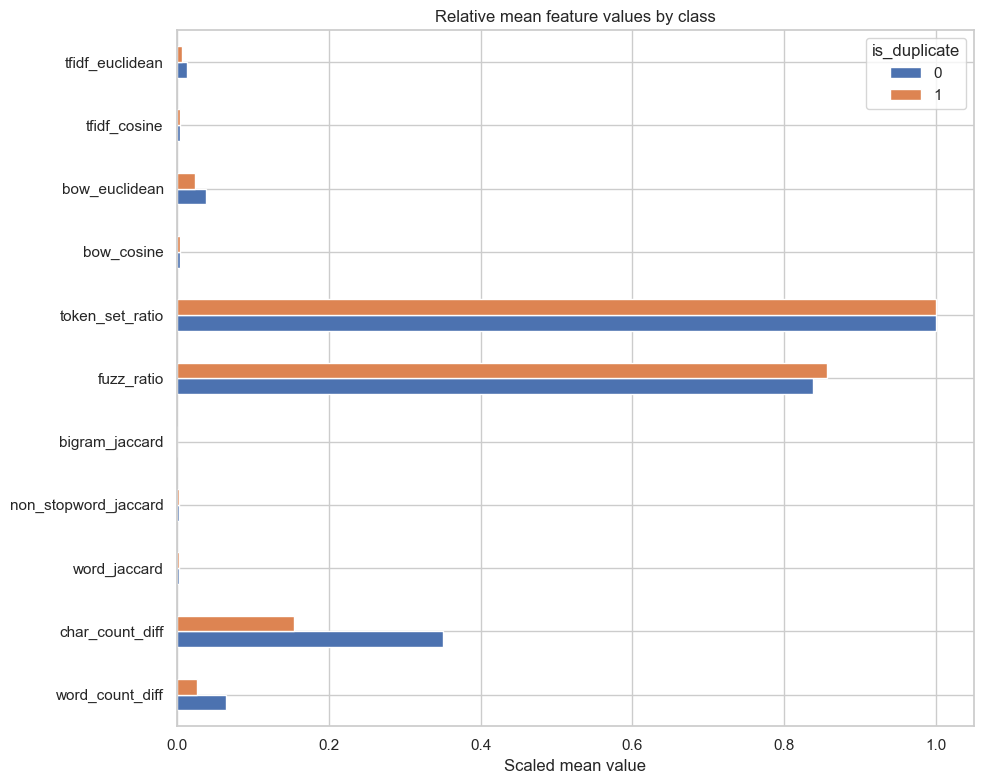

In [17]:
mean_by_class = feature_table.groupby("is_duplicate")[corr_cols].mean().T
scaled_mean_by_class = mean_by_class.copy()

for col in scaled_mean_by_class.columns:
    column = scaled_mean_by_class[col]
    col_min = column.min()
    col_max = column.max()
    if col_max > col_min:
        scaled_mean_by_class[col] = (column - col_min) / (col_max - col_min)

scaled_mean_by_class.plot(kind="barh", figsize=(10, 8))
plt.title("Relative mean feature values by class")
plt.xlabel("Scaled mean value")
plt.tight_layout()
plt.show()

## 8. Pairplot and low-dimensional views of the engineered feature space

These plots are not needed to build the feature table itself, but they are useful for a more visual check of how the engineered feature space behaves.

A small sample is enough here:
- pairplot gives a quick view of a few strong features together;
- PCA shows the broad structure;
- t-SNE gives a more local view of how the two classes mix or separate.

In [18]:
RUN_PAIRPLOT = False

pairplot_features = [
    "word_jaccard",
    "non_stopword_jaccard",
    "fuzz_ratio",
    "token_set_ratio",
    "tfidf_cosine",
]

if RUN_PAIRPLOT:
    pairplot_sample = feature_table[["is_duplicate"] + pairplot_features].sample(
        min(len(feature_table), 2000),
        random_state=42,
    )
    sns.pairplot(pairplot_sample, hue="is_duplicate", corner=True, diag_kind="hist")
    plt.show()

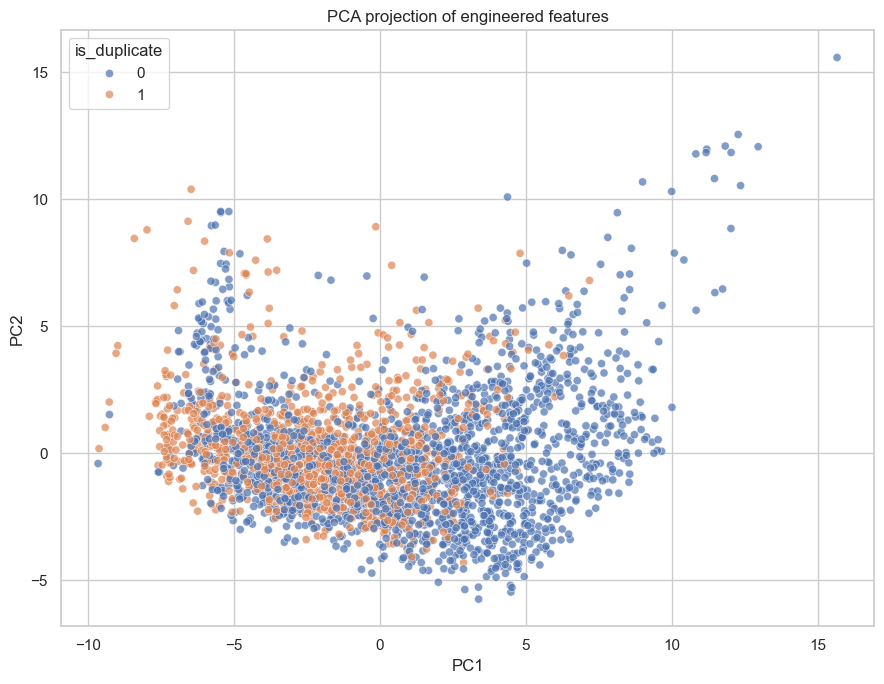

In [19]:
projection_features = [
    col for col in numeric_cols
    if col in feature_table.columns
]

projection_sample = feature_table[["is_duplicate"] + projection_features].sample(
    min(len(feature_table), 3000),
    random_state=42,
).reset_index(drop=True)

X_proj = projection_sample[projection_features].copy()
y_proj = projection_sample["is_duplicate"].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_proj)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["is_duplicate"] = y_proj.values

plt.figure(figsize=(9, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="is_duplicate", s=35, alpha=0.7)
plt.title("PCA projection of engineered features")
plt.tight_layout()
plt.show()

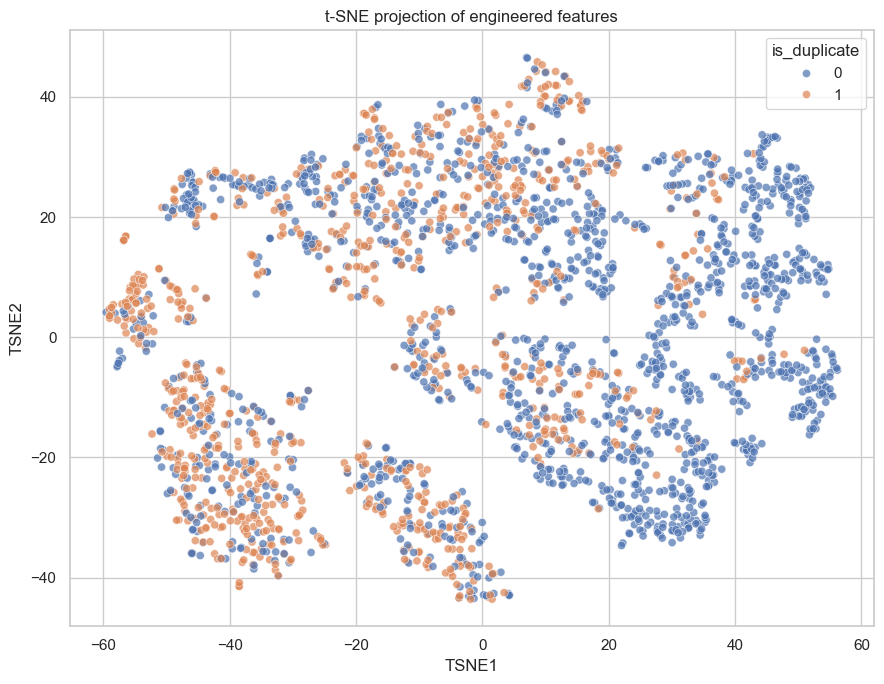

In [20]:
tsne_sample = feature_table[["is_duplicate"] + projection_features].sample(
    min(len(feature_table), 2500),
    random_state=42,
).reset_index(drop=True)

X_tsne = tsne_sample[projection_features].copy()
y_tsne = tsne_sample["is_duplicate"].copy()

scaler = StandardScaler()
X_tsne_scaled = scaler.fit_transform(X_tsne)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42,
)

X_tsne_2d = tsne.fit_transform(X_tsne_scaled)

tsne_df = pd.DataFrame(X_tsne_2d, columns=["TSNE1", "TSNE2"])
tsne_df["is_duplicate"] = y_tsne.values

plt.figure(figsize=(9, 7))
sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="is_duplicate", s=35, alpha=0.7)
plt.title("t-SNE projection of engineered features")
plt.tight_layout()
plt.show()

## 9. Feature engineering summary

This step converted the cleaned question pairs into a reusable numeric feature table.

Main outcomes:
- lexical and length-based pair features were created from the normalized text;
- fuzzy matching features were added to capture close wording and token reordering;
- sparse similarity features were built from BoW and TF-IDF representations;
- the main feature groups were compared visually by class;
- the full feature table was saved for later modeling.

Overall, the dataset is now represented not only as cleaned text, but also as a structured set of similarity signals that can be used directly in model training.